In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from astropy.time import Time

In [2]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [71]:
#crlist = pd.read_csv("/Users/dven/repos/Pulse_Duration_Calibration/data/input/(I)CMEs_SingleEvents.csv")
crlist = pd.read_csv("/Users/dven/repos/Pulse_Duration_Calibration/data/input/(I)CME_filtered.csv")
crlist_met = pd.read_csv("/Users/dven/repos/Pulse_Duration_Calibration/data/input/met.csv")

In [73]:
# Convert date columns to datetime objects using datetime library
date_columns = ['CME_Time', 'Time_21.5', 'ICME_Start_Time', 'ICME_End_Time', 'Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)
    
crlist['tt_icme'] = np.nan 
for irow in range(0, len(crlist)):
    crlist.loc[irow,'tt_icme'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist['tt_icme'] = crlist['tt_icme'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

crlist['v_eff'] = np.nan
distance = (149.597e6 - 21.5*696340)
for irow in range(0, len(crlist)):
    crlist.loc[irow,'v_eff'] = distance/(crlist.loc[irow,'tt_icme']*24*60*60)

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_5768/1648552853.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2 days 19:05:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  crlist.loc[irow,'tt_icme'] = crlist.loc[irow,'Disturbance_Time'] - crlist.loc[irow,'Time_21.5']


In [75]:
crlist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ICME              64 non-null     object        
 1   CME               64 non-null     object        
 2   -                 64 non-null     object        
 3   Disturbance_Time  64 non-null     datetime64[ns]
 4   ICME_Start_Time   64 non-null     datetime64[ns]
 5   ICME_End_Time     64 non-null     datetime64[ns]
 6   V_ICME            64 non-null     int64         
 7   V_max             64 non-null     int64         
 8   B                 64 non-null     int64         
 9   MC                64 non-null     int64         
 10  -                 64 non-null     object        
 11  CME_Time          64 non-null     datetime64[ns]
 12  Time_21.5         64 non-null     datetime64[ns]
 13  lat               64 non-null     int64         
 14  lon               64 non-nul

In [77]:
# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5', 'Disturbance_Time']
for column in date_columns:
    crlist_met[column] = crlist_met[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)
    
crlist_met['tt_icme'] = np.nan 
for irow in range(0, len(crlist_met)):
    crlist_met.loc[irow,'tt_icme'] = crlist_met.loc[irow,'Disturbance_Time'] - crlist_met.loc[irow,'Time_21.5']
# Convert  from timedelta to days
crlist_met['tt_icme'] = crlist_met['tt_icme'].apply(lambda x: x.days + x.seconds / 86400 if isinstance(x, timedelta) else None)

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_5768/1195722659.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2 days 05:50:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  crlist_met.loc[irow,'tt_icme'] = crlist_met.loc[irow,'Disturbance_Time'] - crlist_met.loc[irow,'Time_21.5']


In [79]:
print(crlist_met)

             Time_21.5    Disturbance_Time  CME_V   tt_icme
0  2023-02-11 11:12:00 2023-02-13 17:02:00   1700  2.243056
1  2023-02-24 20:36:00 2023-02-26 18:43:00   1323  1.921528
2  2023-03-13 10:53:00 2023-03-15 03:48:00   1334  1.704861
3  2023-03-20 02:41:00 2023-03-23 09:10:00    602  3.270139
4  2023-03-20 14:42:00 2023-03-23 09:10:00    815  2.769444
5  2023-04-21 18:12:00 2023-04-23 17:00:00   1081  1.950000
6  2023-05-05 08:12:00 2023-05-07 13:20:00    950  2.213889
7  2023-05-09 19:00:00 2023-05-12 05:48:00   1450  2.450000
8  2023-07-10 04:00:00 2023-07-13 15:49:00    900  3.492361
9  2023-07-11 19:24:00 2023-07-14 15:55:00    870  2.854861
10 2023-07-17 23:36:00 2023-07-20 16:07:00   1638  2.688194
11 2023-07-18 20:12:00 2023-07-21 19:25:00   1200  2.967361
12 2023-08-05 07:12:00 2023-08-07 11:07:00   1020  2.163194
13 2023-09-14 07:24:00 2023-09-17 01:53:00    830  2.770139
14 2023-09-22 02:24:00 2023-09-24 19:52:00   1225  2.727778
15 2023-10-16 12:09:00 2023-10-20 07:30:

In [11]:
cr_sorted = crlist.sort_values('ICME_Start_Time').reset_index(drop=True)

t = cr_sorted['ICME_Start_Time']

# Differences forward and backward
dt_prev = t.diff().abs()
dt_next = t.diff(-1).abs()

mask = ~(
    (dt_prev < pd.Timedelta(days=5)) |
    (dt_next < pd.Timedelta(days=5))
)

cr = cr_sorted[mask].reset_index(drop=True)

In [12]:
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ICME              64 non-null     object        
 1   CME               64 non-null     object        
 2   -                 64 non-null     object        
 3   Disturbance_Time  64 non-null     datetime64[ns]
 4   ICME_Start_Time   64 non-null     datetime64[ns]
 5   ICME_End_Time     64 non-null     datetime64[ns]
 6   V_ICME            64 non-null     int64         
 7   V_max             64 non-null     int64         
 8   B                 64 non-null     int64         
 9   MC                64 non-null     int64         
 10  -                 64 non-null     object        
 11  CME_Time          64 non-null     datetime64[ns]
 12  Time_21.5         64 non-null     datetime64[ns]
 13  lat               64 non-null     int64         
 14  lon               64 non-nul

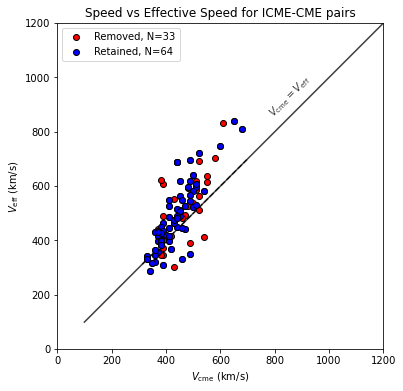

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(crlist['V_ICME'],crlist['v_eff'], c = 'red', edgecolors = 'black', label='Removed, N=33')
ax.scatter(cr['V_ICME'],cr['v_eff'], c = 'blue', edgecolors = 'black', label='Retained, N=64')

# plot y = x line
xmin, xmax = ax.get_xlim()
ax.plot([xmin, xmax], [xmin, xmax], 'k--', alpha=0.75, zorder=0)

# add label along the line
x_text = 1.10 * xmax          # position along x
y_text = 1.10 * x_text               # since y = x
ax.text(
    x_text, y_text,
    r'$V_{\mathrm{cme}} = V_{\mathrm{eff}}$',
    rotation=45,
    color='black',
    alpha=0.8,
    ha='left',
    va='bottom'
)

ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_xlim(0, 1200)
ax.set_ylim(0, 1200)
ax.set_xlabel(r'$V_{\mathrm{cme}}$ (km/s)')
ax.set_ylabel(r'$V_{\mathrm{eff}}$ (km/s)')
ax.set_title('Speed vs Effective Speed for ICME-CME pairs')
ax.set_aspect('equal')
ax.legend()
fig.savefig('filtered_icme.pdf', format='pdf')

In [35]:
cr.to_csv('cr.csv', index=False)

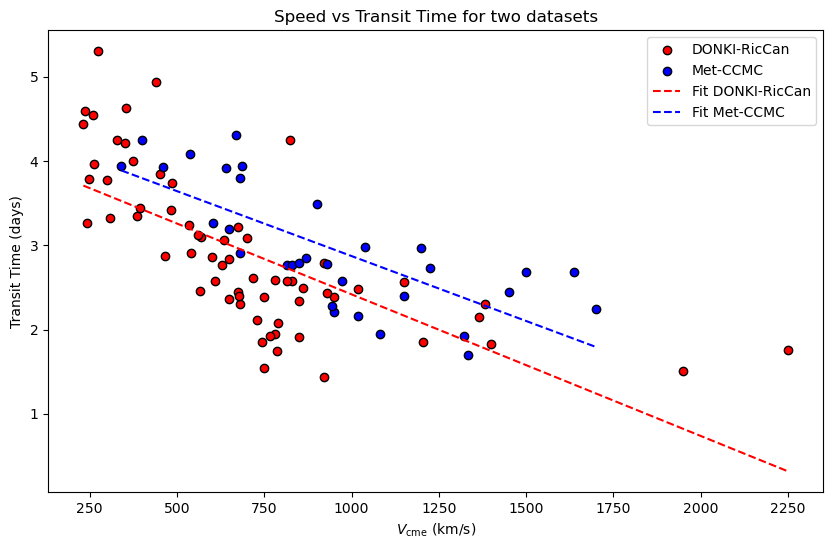

In [81]:
fig, ax = plt.subplots(figsize=(10,6))

# Scatter plots
ax.scatter(crlist['V'], crlist['tt_icme'], c='red', edgecolors='black', label='DONKI-RicCan')
ax.scatter(crlist_met['CME_V'], crlist_met['tt_icme'], c='blue', edgecolors='black', label='Met-CCMC')

# ---- Line of best fit for DONKI-RicCan ----
x1 = crlist['V']
y1 = crlist['tt_icme']

m1, b1 = np.polyfit(x1, y1, 1)     # slope and intercept
x_fit1 = np.linspace(x1.min(), x1.max(), 100)
y_fit1 = m1*x_fit1 + b1

ax.plot(x_fit1, y_fit1, color='red', linestyle='--', label='Fit DONKI-RicCan')

# ---- Line of best fit for Met-CCMC ----
x2 = crlist_met['CME_V']
y2 = crlist_met['tt_icme']

m2, b2 = np.polyfit(x2, y2, 1)
x_fit2 = np.linspace(x2.min(), x2.max(), 100)
y_fit2 = m2*x_fit2 + b2

ax.plot(x_fit2, y_fit2, color='blue', linestyle='--', label='Fit Met-CCMC')

# Labels
ax.set_xlabel(r'$V_{\mathrm{cme}}$ (km/s)')
ax.set_ylabel('Transit Time (days)')
ax.set_title('Speed vs Transit Time for two datasets')
ax.legend()

fig.savefig('v_vs_tt.pdf', format='pdf')